In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Downloads/fuel-econ.csv")
df.head()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,79,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,94,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,0,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8


In [3]:
df.shape

(3929, 20)

### Exercise 1: Encoding 3 numeric variables
Let's look at the relationship between fuel mileage in highway settings (`highway`), engine displacement (`displ`), and co2 emissions (`co2`).  
**Use a _scatter plot_ to depict the data, with a color encoding.**

As you work through this, identify:
1. What is the independent variable?
2. What is most appropriate variable for color encoding?
3. Describe the relationships.

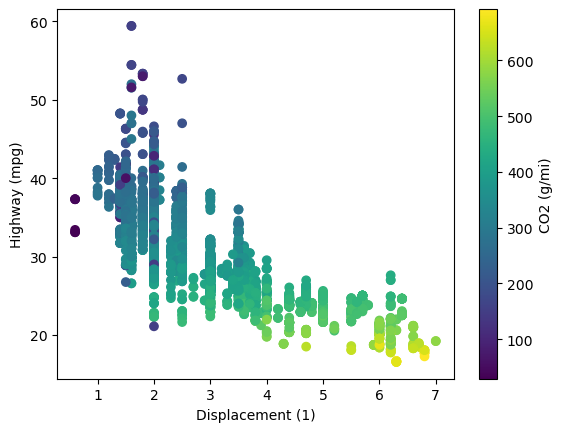

In [6]:
plt.scatter(data=df, x="displ", y="highway", c="co2", cmap="viridis")
plt.colorbar(label="CO2 (g/mi)")
plt.xlabel("Displacement (1)")
plt.ylabel("Highway (mpg)");

1. The engine displacement is the independent variable.
    
2. For color axis I chose carbon emission
    
3. These two variables are correlated, since more efficient engines emit fewer emissions. overall the trend is negative. 

### Exercise 2: Color Encoding
Use a box plot to compare the green house gas rating (`ghgScore`) for Premium and Regular gas cars (`fuelType`) for Ford and Chevrolet (`make`).

For this excercise, you will need to cut or mask your data to select only the `fuelType` and `make` of interest.

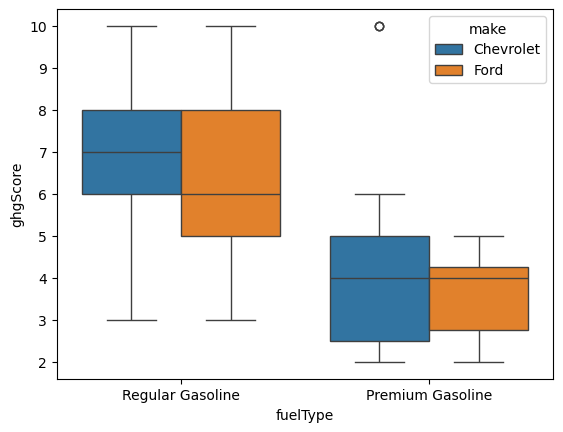

In [9]:
df_subset = df[(df["fuelType"] == "Premium Gasoline") | (df["fuelType"] == "Regular Gasoline")]
df_subset = df_subset[(df_subset["make"] == "Ford") | (df_subset["make"] == "Chevrolet")]

sns.boxplot(data=df_subset, y="ghgScore", x="fuelType", hue="make");

### Exercise 3: Multiple Encoding
Plot the relationship between engine size ('displ', in liters), vehicle class, and fuel type ('fuelType'). For the lattermost feature, focus only on Premium Gasoline and Regular Gasoline cars. What kind of relationships can you spot in this plot?

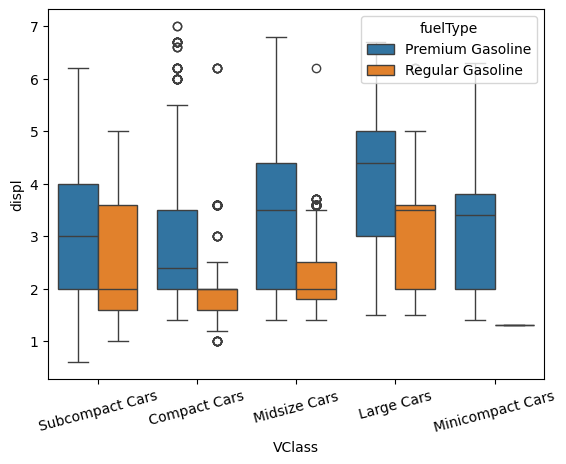

In [12]:
sedan_classes = ["Minicompact Cars", "Subcompact Cars", "Compact Cars", "Midsize Cars", "Large Cars"]
vclasses = pd.CategoricalDtype(ordered=True, categories=sedan_classes)
df["VClass"] = df["VClass"].astype(vclasses);

df_subset1 = df[(df["fuelType"] == "Premium Gasoline") | (df["fuelType"] == "Regular Gasoline")]
sns.boxplot(data=df_subset1, y="displ", x="VClass", hue="fuelType");
plt.xticks(rotation=15);